In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [ ]:
from google.colab import files
Uploaded=files.upload()

Saving Customers.csv to Customers.csv
Saving Orders.csv to Orders.csv


In [ ]:
orders=pd.read_csv("Orders.csv")
customers=pd.read_csv("Customers.csv")
df=pd.merge(orders, customers, on="Order ID" ,how="inner")

In [ ]:

df.shape
df.head()

,Order ID,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode,Order Date,CustomerName,State,City
0,B-25681,1096,658,7,Electronics,Electronic Games,COD,04-06-2018,Bhawna,Madhya Pradesh,Indore
1,B-26055,5729,64,14,Furniture,Chairs,EMI,10-03-2018,Harivansh,Uttar Pradesh,Mathura
2,B-25955,2927,146,8,Furniture,Bookcases,EMI,16-01-2018,Shiva,Maharashtra,Pune
3,B-26093,2847,712,8,Electronics,Printers,Credit Card,27-03-2018,Sarita,Maharashtra,Pune
4,B-25602,2617,1151,4,Electronics,Phones,Credit Card,01-04-2018,Vrinda,Maharashtra,Pune


In [ ]:
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Order ID      1500 non-null   object
 1   Amount        1500 non-null   int64 
 2   Profit        1500 non-null   int64 
 3   Quantity      1500 non-null   int64 
 4   Category      1500 non-null   object
 5   Sub-Category  1500 non-null   object
 6   PaymentMode   1500 non-null   object
 7   Order Date    1500 non-null   object
 8   CustomerName  1500 non-null   object
 9   State         1500 non-null   object
 10  City          1500 non-null   object
dtypes: int64(3), object(8)
memory usage: 129.0+ KB


,0
Order ID,0
Amount,0
Profit,0
Quantity,0
Category,0
Sub-Category,0
PaymentMode,0
Order Date,0
CustomerName,0
State,0


In [ ]:
df.describe()

,Amount,Profit,Quantity
count,1500.000000,1500.00000,1500.000000
mean,291.847333,24.64200,3.743333
std,461.924620,168.55881,2.184942
min,4.000000,-1981.00000,1.000000
25%,47.750000,-12.00000,2.000000
50%,122.000000,8.00000,3.000000
75%,326.250000,38.00000,5.000000
max,5729.000000,1864.00000,14.000000


In [ ]:
df.isnull().sum()

,0
Order ID,0
Amount,0
Profit,0
Quantity,0
Category,0
Sub-Category,0
PaymentMode,0
Order Date,0
CustomerName,0
State,0


In [ ]:
df["Order Date"]=pd.to_datetime(
    df["Order Date"],
    dayfirst=True
)

In [ ]:
df["Month"]=df["Order Date"].dt.month_name()
df["Quarter"]=df["Order Date"].dt.quarter

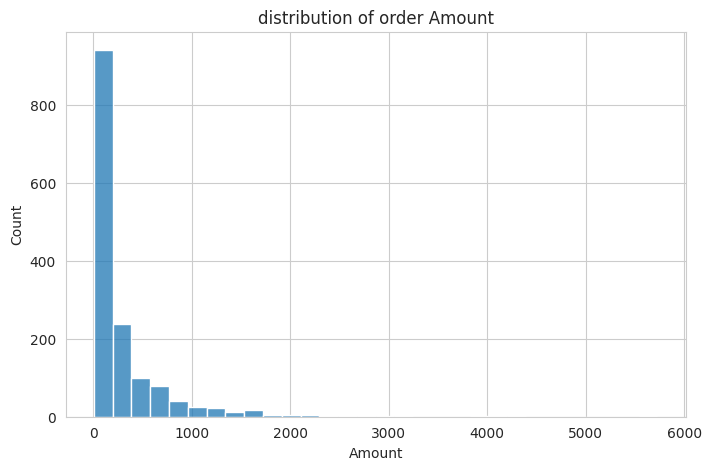

In [ ]:
#Sales Distribution
plt.figure(figsize=(8,5))

sns.histplot(df["Amount"] , bins=30)
plt.title("distribution of order Amount")
plt.show()


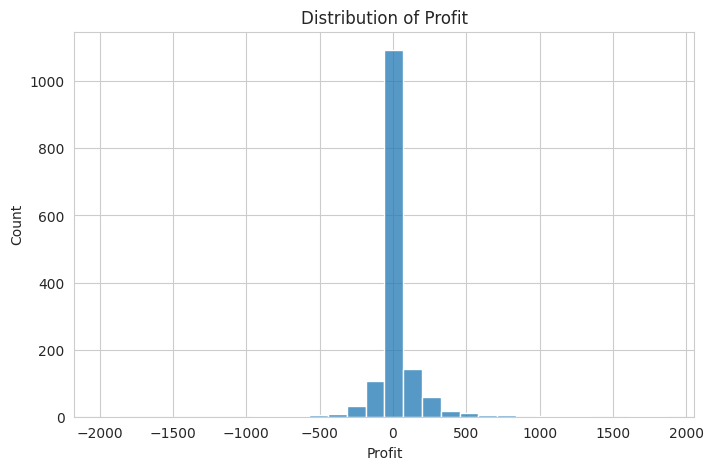

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["Profit"], bins=30)

plt.title("Distribution of Profit")
plt.show()

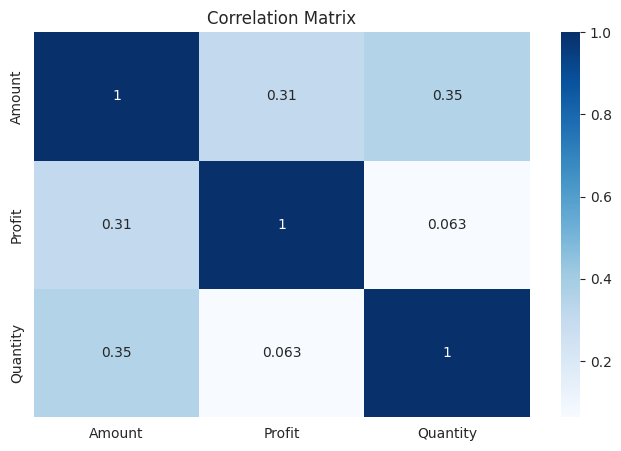

In [ ]:
#Correlation Analysis
numeric_cols=[
    "Amount" ,
    "Profit" ,
    "Quantity"
]

corr=df[numeric_cols].corr()

plt.figure(figsize=(8,5))
sns.heatmap(
    corr,annot=True , cmap="Blues"
)

plt.title("Correlation Matrix")
plt.show()

In [ ]:
customer_sales = (
    df.groupby("CustomerName")["Amount"].sum().sort_values(ascending=False)
)

customer_sales.head(10)

,Amount
CustomerName,
Harivansh,9902
Madhav,9365
Madan Mohan,7766
Shiva,6339
Vishakha,6120
Vrinda,5820
Lalita,5809
Priyanka,5762
Shruti,5750


In [ ]:
customer_sales.describe()

,Amount
count,336.000000
mean,1302.889881
std,1586.349993
min,11.000000
25%,179.750000
50%,719.500000
75%,1654.750000
max,9902.000000


In [ ]:
#Top 5 customers contribute only __ of total revenue.
top5 = (
    customer_sales.head(5).sum()
    / customer_sales.sum()
) * 100

print(top5)

9.021154896052959


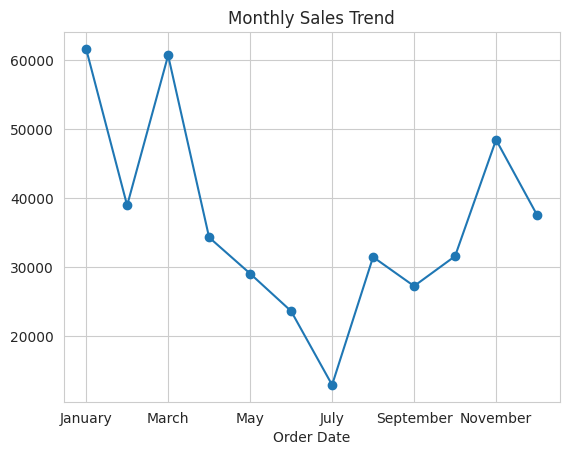

In [ ]:
monthly_sales = df.groupby(df["Order Date"].dt.month_name())["Amount"].sum()

monthly_sales=monthly_sales.reindex([
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'

])

monthly_sales.plot(kind="line" , marker='o')
plt.title("Monthly Sales Trend")
plt.show()

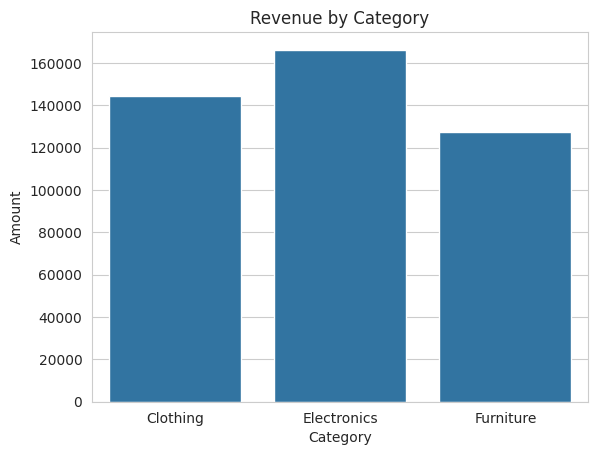

In [ ]:
sns.barplot(
    data=df.groupby("Category")["Amount"].sum().reset_index(),
    x="Category",
    y="Amount"
)

plt.title("Revenue by Category")
plt.show()

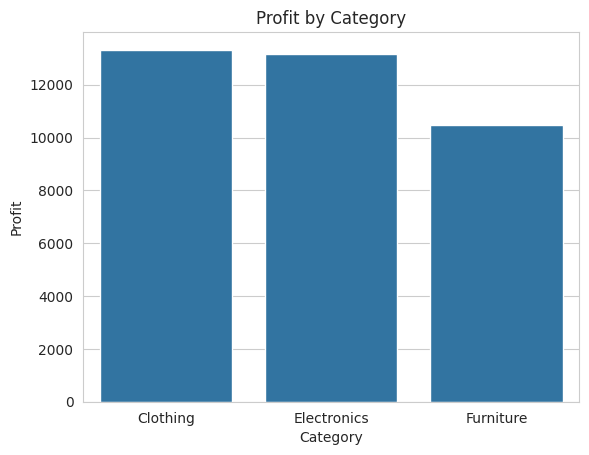

In [ ]:
sns.barplot(
    data=df.groupby("Category")["Profit"].sum().reset_index(),
    x="Category",
    y="Profit"
)
plt.title("Profit by Category")
plt.show()


## Key Findings

In [ ]:
total_revenue = df['Amount'].sum()
total_orders = df['Order ID'].nunique()
print(f"Total revenue reached ₹{total_revenue:,} from {total_orders} orders.")

Total revenue reached ₹437,771 from 500 orders.


In [ ]:
revenue_by_category = df.groupby("Category")["Amount"].sum().sort_values(ascending=False)
profit_by_category = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)

print(f"Highest Revenue Category: {revenue_by_category.index[0]} with ₹{revenue_by_category.iloc[0]:,}")
print(f"Highest Profit Category: {profit_by_category.index[0]} with ₹{profit_by_category.iloc[0]:,}")

Highest Revenue Category: Electronics with ₹166,267
Highest Profit Category: Clothing with ₹13,325


In [ ]:
payment_mode_distribution = df["PaymentMode"].value_counts(normalize=True) * 100
cod_percentage = payment_mode_distribution.get('COD', 0)
print(f"COD accounted for {cod_percentage:.1f}% of all transactions.")

COD accounted for 45.6% of all transactions.


-Revenue showed seasonality with peaks in January and March (as observed from the monthly sales trend plot).
-Customer revenue was well distributed; top 5 customers contributed only 9.0% of total sales.
-Profit had a correlation of 0.06 with quantity sold, indicating low correlation. Profitability depends more on the product mix rather than just sales volume.


